In [ ]:
from pathlib import Path

LOCAL_TRAIN_SAMPLES_DIR = Path("../data/train_samples")
LOCAL_VALID_SAMPLES_DIR = Path("../data/valid_samples")

OUTPUT_DIR = Path("../data/output")
OUTPUT_DIR.mkdir(exist_ok=True)

In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ Memory Growth habilitado para: {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(f"Erro ao configurar memória: {e}")

2025-11-13 11:28:48.196578: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-13 11:28:48.205328: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763044128.215447   77034 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763044128.218879   77034 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763044128.227506   77034 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

✅ Memory Growth habilitado para: 1 GPU(s)


In [ ]:
### Data Parameters
BANDS = ["green_median", "red_median", "nir_median", "swir1_median", "swir2_median", "ndvi_median"],
RESPONSE = ["supervised"]
FEATURES = BANDS + RESPONSE

### Model Hyperparameters
EPOCHS = 50
BATCH_SIZE = 16

KERNEL_SIZE  = 256
KERNEL_SHAPE = [KERNEL_SIZE, KERNEL_SIZE]
COLUMNS = [tf.io.FixedLenFeature(shape=KERNEL_SHAPE, dtype=tf.float32) for k in FEATURES]

FEATURES_DICT = dict(zip(FEATURES, COLUMNS))

In [4]:
def parse_tfrecord(example_proto):
  """The parsing function.
  Read a serialized example into the structure defined by FEATURES_DICT.
  Args:
    example_proto: a serialized Example.
  Returns:
    A dictionary of tensors, keyed by feature name.
  """
  return tf.io.parse_single_example(example_proto, FEATURES_DICT)


def to_tuple(inputs):
  """Function to convert a dictionary of tensors to a tuple of (inputs, outputs).
  Turn the tensors returned by parse_tfrecord into a stack in HWC shape.
  Args:
    inputs: A dictionary of tensors, keyed by feature name.
  Returns:
    A dtuple of (inputs, outputs).
  """
  inputsList = [inputs.get(key) for key in FEATURES]
  
  stacked = tf.stack(inputsList, axis=0)
  stacked = tf.transpose(stacked, [1, 2, 0]) # Convert from CHW to HWC
    
  return stacked[:,:,:len(BANDS)], stacked[:,:,len(BANDS):]


def get_dataset(pattern):
  """Function to read, parse and format to tuple a set of input tfrecord files.
  Get all the files matching the pattern, parse and convert to tuple.
  Args:
    pattern: A file pattern to match in a Cloud Storage bucket.
  Returns:
    A tf.data.Dataset
  """
  glob = tf.io.gfile.glob(pattern)
  dataset = tf.data.TFRecordDataset(glob, compression_type='GZIP',num_parallel_reads=16)
  dataset = dataset.map(parse_tfrecord, num_parallel_calls=16)
  dataset = dataset.map(to_tuple, num_parallel_calls=16)
    
  return dataset

In [ ]:
# It's good practice to have this helper function separate
def squeeze_mask(image, mask):
  """Ensures the mask has the shape [H, W] and not [H, W, 1]."""
  with tf.device('/gpu:0'):
      mask = tf.squeeze(mask, axis=-1)
      mask = tf.cast(mask, tf.uint8)

      return image, mask

def augment_spatial(image, label):
    """Randomly translates/pads the image."""
    # This function expects a 2D label, so we don't need to squeeze inside here anymore.
    with tf.device('/gpu:0'):
    # We add a temporary channel dimension for padding, then remove it.
        label = label[..., tf.newaxis] # Temporarily add back the channel: (256, 256, 1)

        padded_image = tf.pad(image, [[64, 64], [64, 64], [0, 0]], mode='CONSTANT')
        padded_label = tf.pad(label, [[64, 64], [64, 64], [0, 0]], mode='CONSTANT')

        random_x = tf.random.uniform([], 0, 129, dtype=tf.int32)
        random_y = tf.random.uniform([], 0, 129, dtype=tf.int32)

        cropped_image = tf.slice(padded_image, [random_x, random_y, 0], [256, 256, 6])
        cropped_label = tf.slice(padded_label, [random_x, random_y, 0], [256, 256, 1])

        cropped_label = tf.squeeze(cropped_label, axis=-1)

        return cropped_image, cropped_label

def removeNan(image,label):
    image = tf.keras.ops.nan_to_num(image)
    label = tf.keras.ops.nan_to_num(label)
    
    return image,label

def get_training_dataset():
    pattern = LOCAL_TRAIN_SAMPLES_DIR / '*.tfrecord.gz'
    
    dataset = get_dataset(pattern)
    squeezed_dataset = dataset.map(squeeze_mask, num_parallel_calls=tf.data.AUTOTUNE)
    augmented_dataset = squeezed_dataset.map(augment_spatial, num_parallel_calls=tf.data.AUTOTUNE)
    final_dataset = augmented_dataset.concatenate(squeezed_dataset)
    final_dataset = final_dataset.shuffle(20000, reshuffle_each_iteration=True).batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)
    
    return final_dataset.map(removeNan, num_parallel_calls=tf.data.AUTOTUNE)

training = get_training_dataset()

I0000 00:00:1763044129.772448   77034 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13065 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5080, pci bus id: 0000:02:00.0, compute capability: 12.0


In [ ]:
# You still need this helper function to fix the mask shape
def squeeze_and_cast_mask(image, mask):
    """Ensures the mask has the shape [H, W] and not [H, W, 1]."""
    with tf.device('/gpu:0'):
        mask = tf.squeeze(mask, axis=-1)
        mask = tf.cast(mask, tf.uint8)
        return image, mask


def get_eval_dataset():
    """
    Creates the evaluation dataset pipeline.
    NO augmentation, NO concatenation, NO shuffle, NO repeat.
    """
    pattern = LOCAL_VALID_SAMPLES_DIR / '*.tfrecord.gz'

    # 1. Get the initial dataset
    dataset = get_dataset(pattern)

    # 2. Apply the squeeze and cast operation to ensure correct mask shape
    dataset = dataset.map(squeeze_and_cast_mask, num_parallel_calls=tf.data.AUTOTUNE)

    # 3. Batch the data and prefetch for performance
    # The BATCH_SIZE here can be the same or different from your training batch size
    final_dataset = dataset.batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

    return final_dataset.map(removeNan, num_parallel_calls=tf.data.AUTOTUNE)

# You would then create your evaluation dataset like this:
evaluation = get_eval_dataset()

# Construção do modelo

In [ ]:
from keras.models import Model
from keras.layers import Input, Conv2D, UpSampling2D
from keras.applications import MobileNetV3Large

In [8]:
NCLASSES = 76

CONNECTION_POINT_NAME = 'conv_bn'

# --- Part 1: Build the Encoder (your custom feature extractor) ---

mobile_net_v3_large = MobileNetV3Large(include_top=False, input_shape=(256, 256, 3), classes=NCLASSES)
connection_layer = mobile_net_v3_large.get_layer(CONNECTION_POINT_NAME)
tail_model = Model(inputs=connection_layer.input, outputs=mobile_net_v3_large.output, name='mobilenet_tail')

input_layer = Input(shape=(256, 256, len(BANDS)), name='6_band_input')
first_layer = Conv2D(16, (3, 3), strides=(2, 2), padding='same', name='new_first_conv')(input_layer)
encoder_output = tail_model(first_layer)

encoder = Model(inputs=input_layer, outputs=encoder_output, name='encoder')

# --- Part 2: Build the Decoder (NEW PART) ---

x = encoder.output

for itter in range(5):
    x = UpSampling2D(size=(2, 2))(x)
    x = Conv2D(512//(2**itter), (3, 3), activation='relu', padding='same')(x)

# --- Part 3: Add the final segmentation head ---

final_output = Conv2D(NCLASSES, (1, 1), activation='softmax', name='segmentation_head')(x)

# --- Part 4: Create and Compile the final model ---

model = Model(inputs=encoder.input, outputs=final_output)

# --- Part 5: Visualize model summary ---

model.summary()

/home/tiago/miniforge3/envs/mapbiomas/lib/python3.12/site-packages/keras/src/applications/mobilenet_v3.py:519: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ 6_band_input (InputLayer)       │ (None, 256, 256, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ new_first_conv (Conv2D)         │ (None, 128, 128, 16)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_tail (Functional)     │ (None, 8, 8, 960)      │     2,995,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 960)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 16, 16, 512)    │     4,424,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 256)    │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 256, 256, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segmentation_head (Conv2D)      │ (None, 256, 256, 76)   │         2,508 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,990,700 (34.30 MB)

 Trainable params: 8,966,300 (34.20 MB)

 Non-trainable params: 24,400 (95.31 KB)

# Treinamento do modelo

In [9]:
from pathlib import Path

CHECKPOINT_DIR = Path('./checkpoint')
CHECKPOINT_DIR.mkdir(exist_ok=True)

In [10]:
import numpy as np

from PIL import Image
from matplotlib import pyplot as plt

from IPython.display import Image
from keras import metrics, losses
from keras.metrics import MeanIoU

EPOCH = 20

In [11]:
def previewClass(epoch,log):
    counter = 0

    for batch in evaluation.shuffle(10).take(3):
        pureImage = batch[0]
        supervised = batch[1]

        stacked = tf.transpose(pureImage[0], [0, 1, 2]).numpy()
        stackedS = tf.transpose(supervised[0], [0, 1]).numpy()

        test_pred_raw = model.predict(pureImage)
        test_pred_raw = tf.argmax(test_pred_raw, axis=-1)
        test_pred_raw = tf.transpose(test_pred_raw[0],[0, 1]).numpy()

        fig = plt.figure(figsize=[12,4])

        # Visualização da imagem por bandas
        fig.add_subplot(131)
        plt.imshow(stacked[:,:,0:3].astype(np.uint8), interpolation='nearest', vmin=0, vmax=255)

        # Visualização dos labels em cinza
        fig.add_subplot(132)
        plt.imshow(stackedS[:,:], interpolation='nearest',cmap="gray")

        # Visualização da segmentação feita pelo modelo
        fig.add_subplot(133)
        plt.imshow(test_pred_raw[:,:], interpolation='nearest',cmap="gray")

        plt.show()

        counter += 1

In [12]:
# --- Helper function (remains the same) ---
def squeeze_mask(image, mask):
    """Ensures the mask has the shape [H, W] and not [H, W, 1]."""
    mask = tf.squeeze(mask, axis=-1)
    return image, mask

# Assuming get_dataset(glob) is defined elsewhere and works
# from your_module import get_dataset

def run_integrity_check(name, file_glob):
    """
    Iterates through an entire dataset to find shape inconsistencies AND
    invalid numerical values (NaN or Inf).
    """
    print(f"\n--- Starting Full Integrity Check for: {name} ---")

    # 1. Create a dataset pipeline WITHOUT shuffle, batch, or prefetch
    raw_dataset = get_dataset(file_glob)
    # NOTE: We cast to float32 here to check for NaN/Inf before any other processing
    processed_dataset = raw_dataset.map(lambda img, msk: (tf.cast(img, tf.float32), tf.cast(msk, tf.float32)))

    error_found = False
    # 2. Enumerate allows us to see which example number is bad
    for i, (image, mask) in enumerate(processed_dataset):

        # --- NEW: Check for NaN or Inf values ---
        if tf.reduce_any(tf.math.is_nan(image)):
            print(f"!!! NaN VALUE FOUND in IMAGE at example index: {i} !!!")
            error_found = True
            break
        if tf.reduce_any(tf.math.is_inf(image)):
            print(f"!!! Inf VALUE FOUND in IMAGE at example index: {i} !!!")
            error_found = True
            break
        if tf.reduce_any(tf.math.is_nan(mask)):
            print(f"!!! NaN VALUE FOUND in MASK at example index: {i} !!!")
            error_found = True
            break
        if tf.reduce_any(tf.math.is_inf(mask)):
            print(f"!!! Inf VALUE FOUND in MASK at example index: {i} !!!")
            error_found = True
            break
        # --- End of new check ---

        # Squeeze the mask for shape checking
        image, mask = squeeze_mask(image, mask)
        image_shape = image.shape
        mask_shape = mask.shape

        # 3. Check if shapes are correct for every single example
        if len(image_shape) != 3 or image_shape[0] != 256 or image_shape[1] != 256 or image_shape[2] != 6:
            print(f"!!! CORRUPTED IMAGE SHAPE FOUND at example index: {i} !!!")
            print(f"    Expected shape: (256, 256, 6), but got: {image_shape}")
            error_found = True
            break

        if len(mask_shape) != 2 or mask_shape[0] != 256 or mask_shape[1] != 256:
            print(f"!!! CORRUPTED MASK SHAPE FOUND at example index: {i} !!!")
            print(f"    Expected shape: (256, 256), but got: {mask_shape}")
            error_found = True
            break

        # Optional: Print progress every 1000 steps
        if (i + 1) % 1000 == 0:
            print(f"    Checked {i+1} examples... OK")

    if not error_found:
        print(f"--- Full {name} dataset check PASSED. No shape or invalid value errors found. ---")
    else:
        print(f"--- {name} dataset check FAILED. Please investigate the corrupted record. ---")

# --- Run the check on both your datasets ---
training_glob = './train_samples_v1/*.tfrecord.gz'
eval_glob = './eval_samples_v1/*.tfrecord.gz' #<-- MAKE SURE THIS PATH IS CORRECT

run_integrity_check("Training Data", training_glob)
run_integrity_check("Evaluation Data", eval_glob)


--- Starting Full Integrity Check for: Training Data ---


2025-11-13 11:28:54.117520: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:381] TFRecordDataset `buffer_size` is unspecified, default to 262144
2025-11-13 11:28:55.988188: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


--- Full Training Data dataset check PASSED. No shape or invalid value errors found. ---

--- Starting Full Integrity Check for: Evaluation Data ---
--- Full Evaluation Data dataset check PASSED. No shape or invalid value errors found. ---


2025-11-13 11:28:56.995743: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [13]:
import numpy

print("\n--- Verifying Label Range ---")
# Create a dataset WITHOUT batching to check individual masks
raw_training_data = get_dataset('./train_samples_v1/*.tfrecord.gz') # Use your glob
squeezed_training_data = raw_training_data.map(squeeze_mask)

min_label = 999
max_label = -999

# This loop might take a minute
for i, (image, mask) in enumerate(squeezed_training_data):
    current_min = tf.reduce_min(mask)
    current_max = tf.reduce_max(mask)
    if current_min < min_label:
        min_label = current_min
    if current_max > max_label:
        max_label = current_max
    if (i + 1) % 1000 == 0:
        print(f"Scanned {i+1} masks...")

print(f"\nScan Complete. Minimum label found: {min_label}")
print(f"Scan Complete. Maximum label found: {max_label}")


--- Verifying Label Range ---

Scan Complete. Minimum label found: 0.0
Scan Complete. Maximum label found: 75.0


In [14]:
# --- THE ISOLATION EXPERIMENT ---
tensorboard = tf.keras.callbacks.TensorBoard(log_dir='output/', write_images=True)

cp_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=CHECKPOINT_DIR / "cp-{epoch:04d}.keras",
    verbose=1,
    save_weights_only=False,
    save_best_only=False
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    jit_compile=False
)

t_dataset = get_training_dataset()
v_dataset = get_eval_dataset()

In [15]:
with tf.device('/gpu:0'):
    result = model.fit(
        t_dataset,
        epochs=EPOCH,
        initial_epoch=0,
        verbose=1,
        validation_data=v_dataset,
        callbacks=[cp_callback, tensorboard]
    )

Epoch 1/20


I0000 00:00:1763044158.689576   77346 cuda_dnn.cc:529] Loaded cuDNN version 91002


    102/Unknown 35s 148ms/step - accuracy: 0.3536 - loss: 2.9337

2025-11-13 11:29:36.809009: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 12098011557479743082
2025-11-13 11:29:36.809026: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 8563025019911328373
2025-11-13 11:29:36.809028: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 4589553194555874683
2025-11-13 11:29:36.809031: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2025-11-13 11:29:36.809125: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 968071958083446099
/home/tiago/miniforge3/envs/mapbiomas/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can ge


Epoch 1: saving model to checkpoint/cp-0001.keras


...

102/102 ━━━━━━━━━━━━━━━━━━━━ 18s 160ms/step - accuracy: 0.7527 - loss: 0.6792 - val_accuracy: 0.6448 - val_loss: 1.2152
Epoch 20/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.7538 - loss: 0.6712

2025-11-13 11:35:44.252070: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 12098011557479743082
2025-11-13 11:35:44.252103: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 8563025019911328373
2025-11-13 11:35:44.252115: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 4589553194555874683



Epoch 20: saving model to checkpoint/cp-0020.keras


2025-11-13 11:35:45.656523: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 1934754036080223554
2025-11-13 11:35:45.656542: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 5737801649784176857
2025-11-13 11:35:45.656543: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 11057585410915553311


102/102 ━━━━━━━━━━━━━━━━━━━━ 20s 173ms/step - accuracy: 0.7506 - loss: 0.6832 - val_accuracy: 0.6587 - val_loss: 1.1626


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 779ms/step


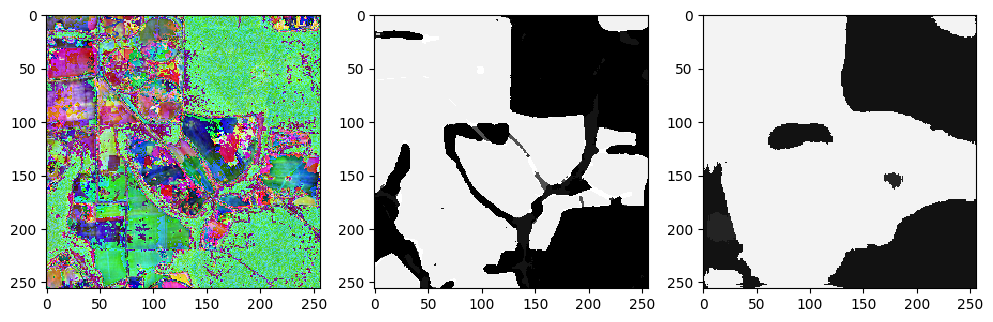

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


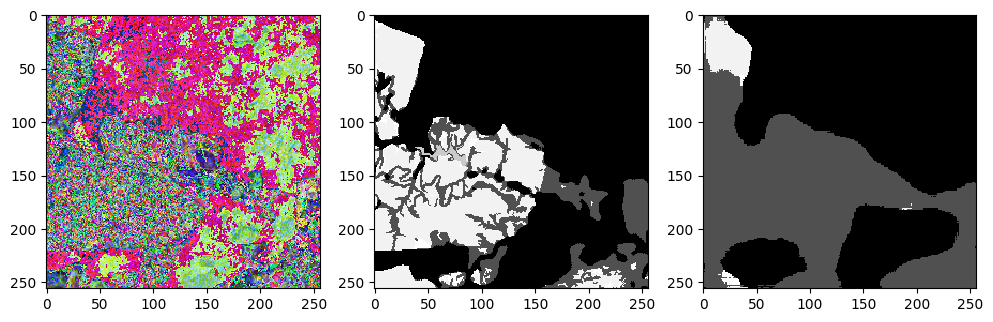

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


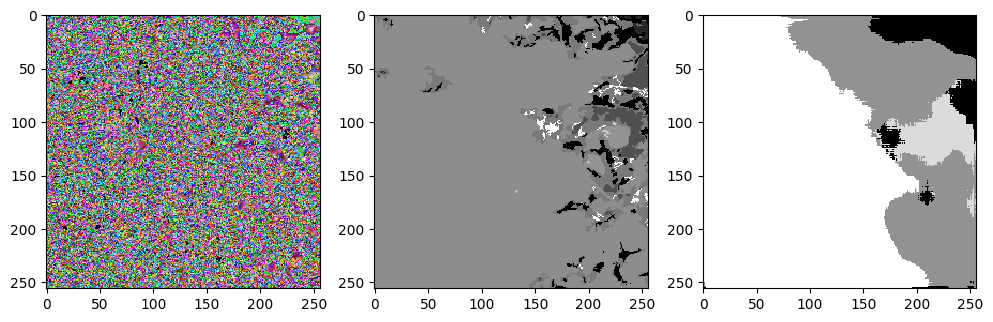

In [16]:
previewClass(1,1)

# Extrator de caracteristicas

In [30]:
TARGET_LAYER_NAME = 'conv2d_2'

try:
    input_tensor = model.input
    output_tensor = model.get_layer(TARGET_LAYER_NAME).output

    new_feature_extractor = Model(
        inputs=input_tensor,
        outputs=output_tensor,
        name=f"extractor_until_{TARGET_LAYER_NAME}"
    )

    print("--- Successfully created new extractor ---")
    new_feature_extractor.summary()

    new_feature_extractor.save('my_model.keras')

except ValueError as e:
    print(f"\n--- ERROR ---")
    print(f"Could not find a layer named '{TARGET_LAYER_NAME}'.")
    print("Please check the name in your model summary and try again.")

--- Successfully created new extractor ---


Model: "extractor_until_conv2d_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ 6_band_input (InputLayer)       │ (None, 256, 256, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ new_first_conv (Conv2D)         │ (None, 128, 128, 16)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_tail (Functional)     │ (None, 8, 8, 960)      │     2,995,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 960)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 16, 16, 512)    │     4,424,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 256)    │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │       295,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,895,936 (33.94 MB)

 Trainable params: 8,871,536 (33.84 MB)

 Non-trainable params: 24,400 (95.31 KB)